# Supplementary figures — copied from `../Supplementary_coloc_examples.ipynb`

**This is a near-verbatim copy of the source notebook**, not a cleaned
reproduction. Only inert cells were removed: empty cells, cells that are
entirely commented out, and cells that only `print()` or display a table.
Every cell that computes or plots anything is untouched.

Panels produced here: `sup_breast-cancer*` (6), `sup_hyperthyroid*` (7)

Two mechanical path edits were applied so the notebook runs from this directory
and cannot overwrite the published figures:

* `../code/...` → `../../code/...` (this notebook sits one level deeper)
* `../code/plots/` → `plots/` and `../code/revision_plots/` → `revision_plots/`

Cells unrelated to the supplementary panels were **kept**, so this notebook may
compute more than it needs to. That is the trade for not re-tracing it.

In [23]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import tabix
import gzip
import vcf

In [24]:

def plot_isoform_annotations(annotation_exons, gene, colores=None, start=None, end=None, 
                             figsize=None, lwidth=5, iso_order=None, axes=None, xlim=None):

    gene_exons = annotation_exons.loc[annotation_exons.gene_id == gene]

    if iso_order is None:
        isoforms = sorted(gene_exons.transcript_id.unique())
    else:
        isoforms = iso_order

    isoform_dict = {}
    for i, iso in enumerate(isoforms):
        isoform_name = f'isoform_{str(i+1)}'
        df = gene_exons.loc[gene_exons.transcript_id == iso].copy()
        df['transcript_id'] =  f'{gene}.{isoform_name}'
        isoform_dict.update({isoform_name:{'df':df}})

    try:
        chrom = list(annotation_exons.chrom)[0]
    except:
        chrom = list(annotation_exons['#chrom'])[0]
    if start is None:
        start = str(np.min([int(list(gene_exons.start)[0]), int(list(gene_exons.start)[0])]) - 1000)
    if end is None:
        end = str(np.max([int(list(gene_exons.end)[-1]), int(list(gene_exons.end)[-1])]) + 1000)

    coords = [f'{chrom}:{start}', f'{chrom}:{end}']

    # print(isoform_dict)

    plot_gene_isoforms(isoform_dict, coords, color_list = colores, figsize=figsize, lwidth=lwidth, axes=axes, xlim=xlim)


def plot_gene_isoforms(isoforms_dict, coordinates, color_list = None, axes=None, figsize=None, lwidth=5, xlim=None):


    if xlim is None:
        xlim1 = int(coordinates[0].split(':')[1])
        xlim2 = int(coordinates[-1].split(':')[1])
#         print(xlim)
    else:
        xlim1 = xlim[0]
        xlim2 = xlim[1]
    

    if color_list is None:
        color_list = sns.color_palette("tab10")

    K = len(isoforms_dict)

    if figsize is None:
        figsize=(20, 3)

    if axes is None:
        fig, axes = plt.subplots(K, 1, figsize=figsize)

    for i in range(K):
        isoform_df = isoforms_dict[f'isoform_{str(i+1)}']['df']
        # print(isoform_df)
        ax = axes[i]
        color = color_list[i]
        plot_isoform(isoform_df, ax, color, xlim1, xlim2, lwidth=lwidth)


def plot_isoform(isoform_df, ax, color, xlim1, xlim2, lwidth):
    # print(isoform_df)
    is_first = True
    for idx, row in isoform_df.iterrows():
        start = int(row.start)
        end = int(row.end)
        if is_first:
            first = end
            is_first = False
    
        ax.fill_between([start, end], [0, 0], [1, 1], color = color, zorder=2)
    
    ax.plot([first, start], [0.5, 0.5], c=color, linewidth=lwidth)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['bottom', 'top', 'right', 'left']].set_visible(False)
    ax.set_xlim([xlim1, xlim2])

    # print(xlim1, xlim2)


In [25]:
import tabix

# Open the Tabix file
tabix_file = tabix.open('../../code/results/coloc/qtls/Brain-CerebellarHemisphere/leafcutter.NominalPass/chr11.txt.tabix.gz')

# Define a function to read the content
def run_tabix(tabix_file, chrom, start, end, file_type = 'other'):
    tabix_obj = tabix.open(tabix_file)
    # Fetch data from the tabix file in the desired range
    result = tabix_obj.query(chrom, start, end)
    
    rows = [line for line in result]
    
    with gzip.open(tabix_file) as fh:
        cols = fh.readline().decode().rstrip().split('\t')
    
    df = pd.DataFrame(rows, columns=cols)  # Add correct column names
    if file_type == 'leafcutter':
        df['gid'] = df.pid.apply(lambda x: x.split(':')[3])
    elif file_type == 'expression':
        df['gid'] = df.pid.apply(lambda x: x.split('.')[0])
        
    return df

def get_best_snp_record(vcf, snp):
    
    chrom, location = snp.split(':')
    location = int(location)
    
    record_list = []
    for record in vcf.fetch(chrom, location-1, location+1):  
        if record.POS == location:
#             print(chrom, location)
            return [record]
        record_list.append(record)
        
    return record_list

   
def make_boxplot_df(qqnorm_data, phenotype, record, phenotype_class='',
                    color_by_phenotype=False, color='black'):
    # `color` follows the Fig. 4e convention: tab:red for unproductive
    # splicing, tab:blue for expression. Box faces stay white and the
    # median stays black; the colour is carried by outlines and points.
    try:
        qqnorm_data = qqnorm_data.set_index('pid')
    except:
        print('nothing')
    qq_samples = qqnorm_data.columns[6:]
    hom_refs = [str(x.sample) for x in record.get_hom_refs() if str(x.sample) in qq_samples]
    hets = [str(x.sample) for x in record.get_hets() if str(x.sample) in qq_samples]
    hom_alts = [str(x.sample) for x in record.get_hom_alts() if str(x.sample) in qq_samples]
    
    samples = hom_refs + hets + hom_alts
    
    ref = record.REF
    alt = record.ALT[0]
    
    genotype = [str(ref) + ',' + str(ref)]*len(hom_refs)
    genotype += [str(ref) + ',' + str(alt)]*len(hets)
    genotype += [str(alt) + ',' + str(alt)]*len(hom_alts)
    
    df = pd.DataFrame()
    df['genotype'] = genotype
    df['qqnorm'] = list(qqnorm_data.loc[phenotype, samples].astype(float))
    df.index = hom_refs + hets + hom_alts

    # return df
    
    if color_by_phenotype:
        colores = [color_by_phenotype]*3

    else:
        colores = ['red', 'purple', 'blue']#ColorPallette#list(plt.get_cmap('tab10').colors)
    
    
    
    # plt.figure(figsize=(2.5, 2.5))
    fig, ax = plt.subplots(figsize=(2.5, 2.5), dpi=300)
    
    sns.boxplot(x = 'genotype', y = 'qqnorm', data = df, width=.5, fliersize=0, 
                     linewidth=2,  boxprops=dict(facecolor='white', edgecolor=color),
                whiskerprops=dict(color=color), capprops=dict(color=color),
                medianprops=dict(linewidth=2, color='black'), ax=ax)#, palette=colorbrewer)

    

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.tick_params(size=4, width=2, labelsize=14)
    # sns.despine(offset=5, trim=True)
    sns.stripplot(x = 'genotype', y = 'qqnorm', data = df, alpha=0.9, edgecolor=color,
                  facecolor='none', linewidth=1, ax=ax, rasterized=True)
    # ax.set_yticks([-1, 0, 1])
    # plt.title(phenotype_class + ': ' +phenotype, size=14)
    # n per genotype, under each tick -- same convention as Fig. 4e
    counts = df.genotype.value_counts()
    order = [t.get_text() for t in ax.get_xticklabels()]
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f'{g}\nn={counts[g]}' for g in order])

    return ax

vcf_gtex = vcf.Reader(open("/project/yangili1/cdai/genome_index/hs38/GTEx_v7/GTEx_Analysis_2017-06-05_v8_WGS_VCF_files_GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.vcf.gz", 'br'))


QTL_DIR = '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/qtls'


def nominal_qtl_stats(tissue, kind, phenotype, snp):
    """Nominal-pass beta and P for one phenotype-variant pair.

    `kind` is 'leafcutter' or 'expression'; `snp` is 'chr11:611503'. Returns
    (beta, pval), or (None, None) when the pair was not tested.

    These are the NOMINAL statistics for the exact variant on the x axis, not
    the phenotype-level permutation-pass values, so the annotation describes the
    genotypes actually plotted.
    """
    chrom, pos = snp.split(':')
    pos = int(pos)
    f = f'{QTL_DIR}/{tissue}/{kind}.NominalPass/{chrom}.txt.tabix.gz'
    with gzip.open(f) as fh:
        cols = fh.readline().decode().rstrip().split('\t')
    for row in tabix.open(f).query(chrom, pos - 1, pos + 1):
        d = dict(zip(cols, row))
        if d['#phe_id'] == phenotype and int(d['var_from']) == pos:
            return float(d['slope']), float(d['nom_pval'])
    return None, None


def fmt_qtl(beta, pval):
    """beta / P annotation, in the Fig. 4e format."""
    if beta is None:
        return ''
    exp = int(f'{pval:e}'.split('e')[1])
    mant = pval / (10 ** exp)
    return r'$\beta = ' + f'{beta:.2f}' + r'$' + '\n' + f'P = {mant:.1f}' + r'$\times 10^{' + str(exp) + r'}$'


In [26]:
nom_df = pd.read_csv('../../code/results/coloc/hyprcoloc_results/tables/up_results.tsv.gz', sep='\t')

In [27]:
best_df = nom_df.loc[(nom_df.distance <= 3000) & (nom_df.itype == 'UP') & (((nom_df.sQTL_beta >= 0.01) & (nom_df.eQTL_beta <= -0.01)) | ((nom_df.sQTL_beta <= -0.01) & (nom_df.eQTL_beta >= 0.01)))]
best_df2 = nom_df.loc[(nom_df.distance <= 3000) & (nom_df.itype == 'PR') & (((nom_df.sQTL_beta >= 0.01) & (nom_df.eQTL_beta >= 0.01)) | ((nom_df.sQTL_beta <= -0.01) & (nom_df.eQTL_beta <= -0.01)))]

# Hypothyroidism

In [28]:
gwas = run_tabix('../../code/resources/gwas/StatsForColoc/Hypothyroidism.standardized.txt.tabix.gz', 
          'chr11', 578759-500000, 578759+1000000)

gwas['snp_pos'] = gwas.chrom + ':' + gwas.start

gwas_pval = run_tabix('../../code/resources/gwas/hg38_summary_stats/Hypothyroidism.bed.gz', 
          'chr11', 578759-500000, 578759+1000000)

gwas_pval['snp_pos'] = gwas_pval['chrom'] + ':' + gwas_pval.start

nom = run_tabix('../../code/results/coloc/qtls/Thyroid/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)
nom['snp_pos'] = nom.var_chr + ':' + nom.var_from


nom_e = run_tabix('../../code/results/coloc/qtls/Thyroid/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)
nom_e['snp_pos'] = nom_e.var_chr + ':' + nom_e.var_from
nom['gwas_trait'] = nom['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_e['gwas_trait'] = nom_e['#phe_id'].apply(lambda x: x.split(':')[-1])



nom_wb = run_tabix('../../code/results/coloc/qtls/WholeBlood/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)
nom_wb['snp_pos'] = nom_wb.var_chr + ':' + nom_wb.var_from
nom_wb['gwas_trait'] = nom_wb['#phe_id'].apply(lambda x: x.split(':')[-1])

nom_sp = run_tabix('../../code/results/coloc/qtls/Spleen/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)
nom_sp['snp_pos'] = nom_sp.var_chr + ':' + nom_sp.var_from

nom_sp['gwas_trait'] = nom_sp['#phe_id'].apply(lambda x: x.split(':')[-1])

In [29]:
nom = nom.loc[(nom.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom['#phe_id'] == 'chr11:614037:614475:clu_22612_-:UP:chr11_578759_N_N_Hypothyroidism')]
nom_e = nom_e.loc[(nom_e.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_e['#phe_id'].apply(lambda x: ('ENSG00000185507' in x) and ('chr11_578759_N_N_Hypothyroidism' in x)))]

nom_wb = nom_wb.loc[(nom_wb.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_wb['#phe_id'] == 'chr11:614037:614475:clu_19954_-:UP:chr11_578759_N_N_Hypothyroidism')]
# nom_wb_e = nom_wb_e.loc[(nom_wb_e.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_wb_e['#phe_id'].apply(lambda x: ('ENSG00000185507' in x) and ('chr11_578759_N_N_Hypothyroidism' in x)))]

# nom_lcl = nom_lcl.loc[(nom_lcl.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_lcl['#phe_id'] == 'chr11:614037:614475:clu_18165_-:UP:chr11_578759_N_N_Hypothyroidism')]
# nom_lcl_e = nom_lcl_e.loc[(nom_lcl_e.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_lcl_e['#phe_id'].apply(lambda x: ('ENSG00000185507' in x) and ('chr11_578759_N_N_Hypothyroidism' in x)))]

nom_sp = nom_sp.loc[(nom_sp.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_sp['#phe_id'] == 'chr11:614037:614475:clu_20133_-:UP:chr11_578759_N_N_Hypothyroidism')]
# nom_sp_e = nom_sp_e.loc[(nom_sp_e.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_sp_e['#phe_id'].apply(lambda x: ('ENSG00000185507' in x) and ('chr11_578759_N_N_Hypothyroidism' in x)))]

snps = pd.Index(nom.snp_pos).intersection(pd.Index(gwas_pval.snp_pos)).intersection(pd.Index(gwas.snp_pos)).intersection(pd.Index(nom_e.snp_pos)).intersection(pd.Index(nom_wb.snp_pos)).intersection(pd.Index(nom_sp.snp_pos))

gwas_pval = gwas_pval.groupby('snp_pos').first()
nom = nom.groupby('snp_pos').first()
nom_e = nom_e.groupby('snp_pos').first()
nom_wb = nom_wb.groupby('snp_pos').first()
nom_sp = nom_sp.groupby('snp_pos').first()


In [30]:
LD = pd.read_csv('../../code/results/coloc/LD/chr11_578759_N_N_Hypothyroidism.tsv.gz', sep='\t')
LD.columns = [':'.join(x.split('_')[:2]) for x in LD.columns]
LD.index = LD.columns
LD = LD.astype(float)**2

snps_shared = snps.intersection(LD.columns)



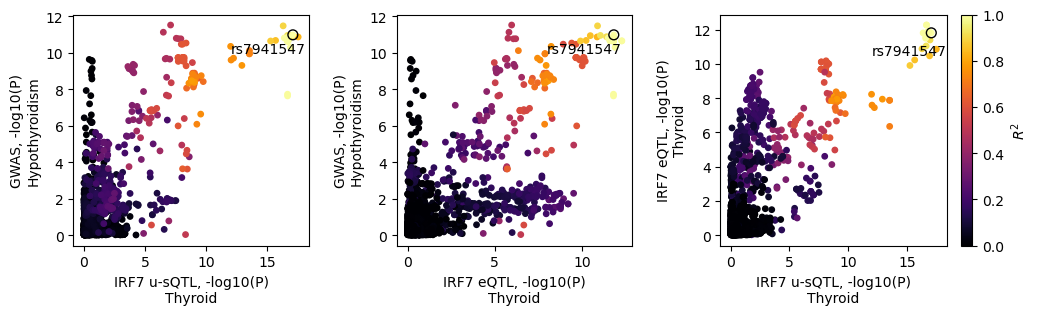

In [31]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2])
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0, rasterized=True)
# plt.colorbar(c)
ax[0].set_xlabel('IRF7 u-sQTL, -log10(P)\nThyroid')
ax[0].set_ylabel('GWAS, -log10(P)\nHypothyroidism')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:611503']].P.astype(float)))
x_r = -np.log10(np.array(nom.loc[['chr11:611503']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(12, 10, 'rs7941547')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]
c=ax[1].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0, rasterized=True)
# plt.colorbar(c)
ax[1].set_xlabel('IRF7 eQTL, -log10(P)\nThyroid')
ax[1].set_ylabel('GWAS, -log10(P)\nHypothyroidism')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:611503']].P.astype(float)))
x_r = -np.log10(np.array(nom_e.loc[['chr11:611503']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(8, 10, 'rs7941547')



x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]
c=ax[2].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0, rasterized=True)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('IRF7 u-sQTL, -log10(P)\nThyroid')
ax[2].set_ylabel('IRF7 eQTL, -log10(P)\nThyroid')

x_r = -np.log10(np.array(nom.loc[['chr11:611503']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_e.loc[['chr11:611503']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(12, 10.5, 'rs7941547')

fig.subplots_adjust(wspace=0.35, hspace=5)

plt.savefig('plots/sup_hyperthyroid.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid.svg', dpi=300, bbox_inches='tight') 

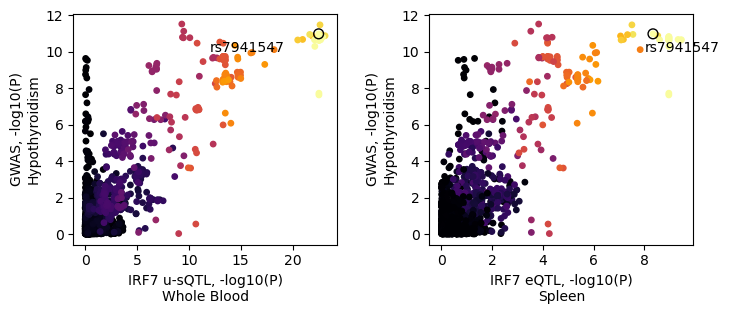

In [32]:
fig, ax = plt.subplots(ncols= 2, figsize=(8, 3), width_ratios=[1, 1])
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_wb.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0, rasterized=True)
# plt.colorbar(c)
ax[0].set_xlabel('IRF7 u-sQTL, -log10(P)\nWhole Blood')
ax[0].set_ylabel('GWAS, -log10(P)\nHypothyroidism')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:611503']].P.astype(float)))
x_r = -np.log10(np.array(nom_wb.loc[['chr11:611503']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(12, 10, 'rs7941547')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_sp.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]
c=ax[1].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0, rasterized=True)
# plt.colorbar(c)
ax[1].set_xlabel('IRF7 eQTL, -log10(P)\nSpleen')
ax[1].set_ylabel('GWAS, -log10(P)\nHypothyroidism')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:611503']].P.astype(float)))
x_r = -np.log10(np.array(nom_sp.loc[['chr11:611503']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(8, 10, 'rs7941547')



fig.subplots_adjust(wspace=0.35, hspace=5)

plt.savefig('plots/sup_hyperthyroid2.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid2.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid2.svg', dpi=300, bbox_inches='tight') 

In [33]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr11', 614037-30000, 614475+30000)

qqnorm = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Thyroid/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='leafcutter')

qqnorm_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Thyroid/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='expression')

qqnorm_wb = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/WholeBlood/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='leafcutter')


qqnorm_lcl = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Cells-EBV-transformedlymphocytes/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='leafcutter')

qqnorm_lcl_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Cells-EBV-transformedlymphocytes/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='expression')


qqnorm_sp = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Spleen/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='leafcutter')


In [34]:
slope = float(nom.loc['chr11:611503'].slope)
slope_se=float(nom.loc['chr11:611503'].slope_se)

In [35]:
slope_se=float(nom.loc['chr11:611503'].slope_se)

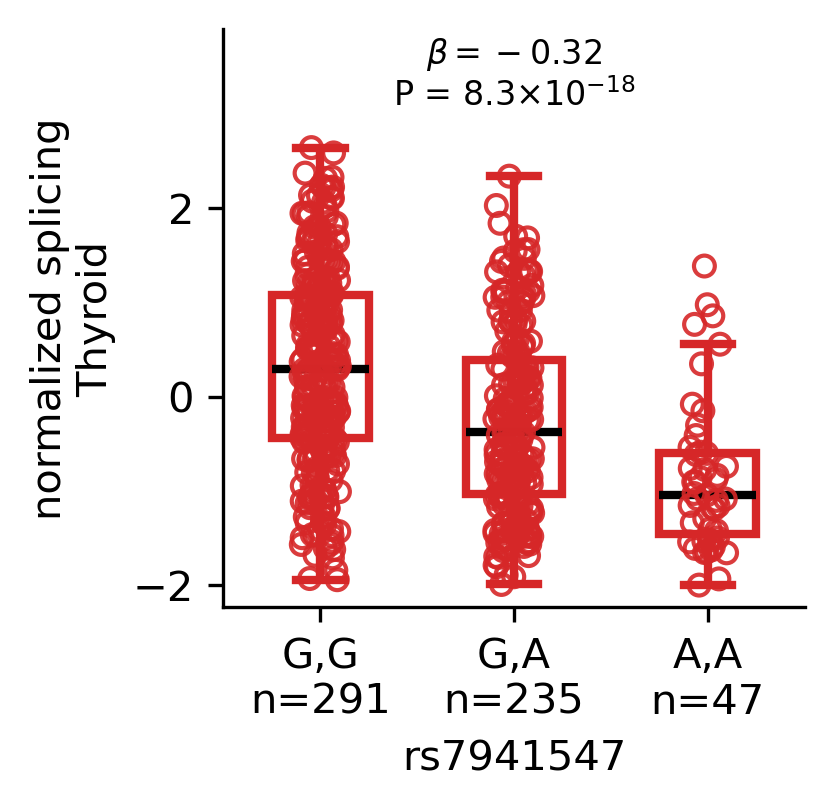

In [36]:
from scipy.stats import t

records = get_best_snp_record(vcf_gtex, 'chr11:611503')

ax = make_boxplot_df(qqnorm, 'chr11:614037:614475:clu_22612_-:UP:chr11_578759_N_N_Hypothyroidism', records[0], color='tab:red')
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nThyroid')






_b, _p = nominal_qtl_stats('Thyroid', 'leafcutter',
                           'chr11:614037:614475:clu_22612_-:UP:chr11_578759_N_N_Hypothyroidism', 'chr11:611503')
if _b is not None:
    _yb, _yt = ax.get_ylim(); ax.set_ylim(_yb, _yt + 0.20 * (_yt - _yb))
    ax.text(0.5, 0.99, fmt_qtl(_b, _p), transform=ax.transAxes,
            ha='center', va='top', fontsize=8)

plt.savefig('plots/sup_hyperthyroid_thyroid_splicing.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid_thyroid_splicing.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid_thyroid_splicing.svg', dpi=300, bbox_inches='tight') 

In [37]:
slope = float(nom_e.loc['chr11:611503'].slope)
slope_se=float(nom_e.loc['chr11:611503'].slope_se)

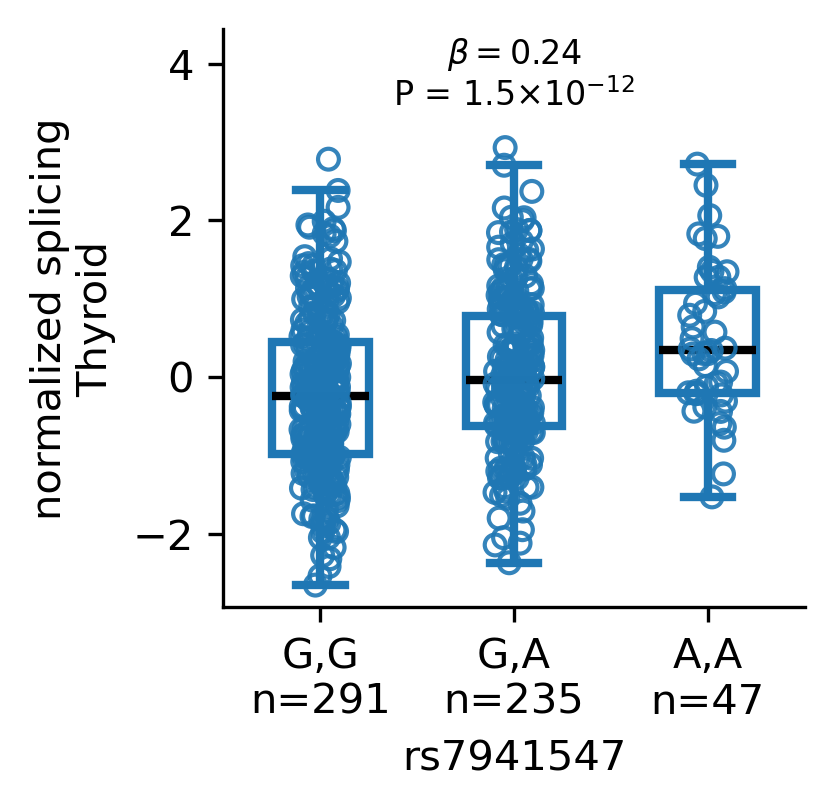

In [38]:
slope = float(nom_e.loc['chr11:611503'].slope)
slope_se=float(nom_e.loc['chr11:611503'].slope_se)

records = get_best_snp_record(vcf_gtex, 'chr11:611503')

ax = make_boxplot_df(qqnorm_e, 'ENSG00000185507.21:chr11_578759_N_N_Hypothyroidism', records[0], color='tab:blue')
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nThyroid')








_b, _p = nominal_qtl_stats('Thyroid', 'expression',
                           'ENSG00000185507.21:chr11_578759_N_N_Hypothyroidism', 'chr11:611503')
if _b is not None:
    _yb, _yt = ax.get_ylim(); ax.set_ylim(_yb, _yt + 0.20 * (_yt - _yb))
    ax.text(0.5, 0.99, fmt_qtl(_b, _p), transform=ax.transAxes,
            ha='center', va='top', fontsize=8)

plt.savefig('plots/sup_hyperthyroid_thyroid_expression.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid_thyroid_expression.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid_thyroid_expression.svg', dpi=300, bbox_inches='tight') 

In [39]:
[x for x in qqnorm_wb.pid if ('hr11_578759_N_N_Hypothyroidism' in x) and ('chr11:614037:614475' in x)]

['chr11:614037:614475:clu_19954_-:UP:chr11_578759_N_N_Hypothyroidism']

In [40]:
nom_sp.loc['chr11:611503'].nom_pval
slope = float(nom.loc['chr11:611503'].slope)
slope_se=float(nom.loc['chr11:611503'].slope_se)

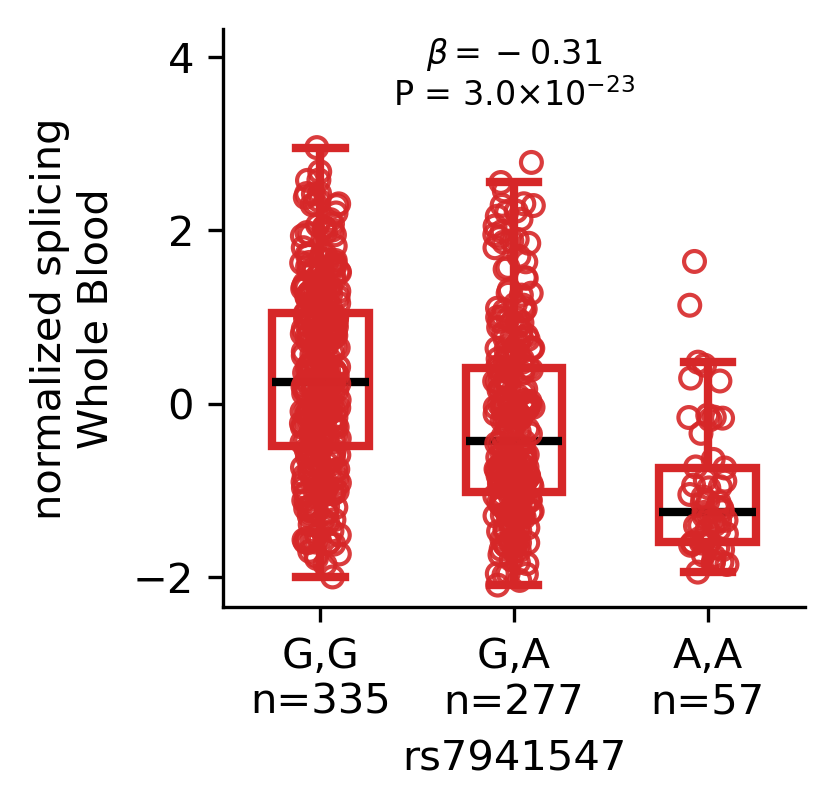

In [41]:
records = get_best_snp_record(vcf_gtex, 'chr11:611503')

ax = make_boxplot_df(qqnorm_wb, 'chr11:614037:614475:clu_19954_-:UP:chr11_578759_N_N_Hypothyroidism', records[0], color='tab:red')
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nWhole Blood')







_b, _p = nominal_qtl_stats('WholeBlood', 'leafcutter',
                           'chr11:614037:614475:clu_19954_-:UP:chr11_578759_N_N_Hypothyroidism', 'chr11:611503')
if _b is not None:
    _yb, _yt = ax.get_ylim(); ax.set_ylim(_yb, _yt + 0.20 * (_yt - _yb))
    ax.text(0.5, 0.99, fmt_qtl(_b, _p), transform=ax.transAxes,
            ha='center', va='top', fontsize=8)

plt.savefig('plots/sup_hyperthyroid_wholeblood_splicing.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid_wholeblood_splicing.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid_wholeblood_splicing.svg', dpi=300, bbox_inches='tight') 

In [ ]:
# sup_hyperthyroid_spleen_splicing -- the Spleen counterpart of the Thyroid and
# Whole Blood panels above. The published figure exists in code/plots/ but the
# cell that made it was lost; this rebuilds it.
#
# Same intron (chr11:614037-614475) and same lead SNP, but the cluster id is
# per-tissue: clu_22612 in Thyroid, clu_19954 in Whole Blood, clu_20133 here.

records = get_best_snp_record(vcf_gtex, 'chr11:611503')

ax = make_boxplot_df(qqnorm_sp, 'chr11:614037:614475:clu_20133_-:UP:chr11_578759_N_N_Hypothyroidism', records[0], color='tab:red')
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nSpleen')

_b, _p = nominal_qtl_stats('Spleen', 'leafcutter',
                           'chr11:614037:614475:clu_20133_-:UP:chr11_578759_N_N_Hypothyroidism', 'chr11:611503')
if _b is not None:
    _yb, _yt = ax.get_ylim(); ax.set_ylim(_yb, _yt + 0.20 * (_yt - _yb))
    ax.text(0.5, 0.99, fmt_qtl(_b, _p), transform=ax.transAxes,
            ha='center', va='top', fontsize=8)

plt.savefig('plots/sup_hyperthyroid_spleen_splicing.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid_spleen_splicing.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid_spleen_splicing.svg', dpi=300, bbox_inches='tight')

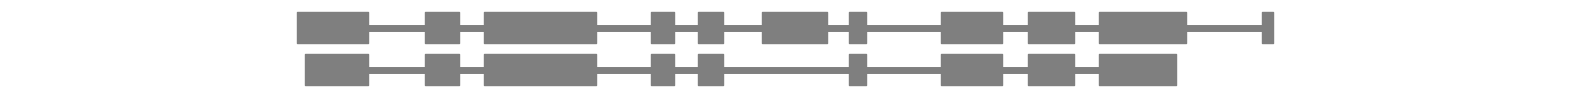

In [42]:
plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000525445','ENST00000469048',])], 
                         'ENSG00000185507', 
                         colores=['tab:gray', 'tab:gray'],  figsize=(20, 1), lwidth=5, 
                         iso_order=['ENST00000525445','ENST00000469048'])

plt.savefig('plots/sup_hyperthyroid_gene.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid_gene.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid_gene.svg', dpi=300, bbox_inches='tight') 

# Breast cancer

In [43]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr11', 802376-30000, 802542+30000)

qqnorm = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Pituitary/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='leafcutter')

qqnorm_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Pituitary/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='expression')

qqnorm_wb = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/WholeBlood/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='leafcutter')

qqnorm_wb_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/WholeBlood/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='expression')


qqnorm_lcl = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Cells-EBV-transformedlymphocytes/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='leafcutter')

qqnorm_lcl_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Cells-EBV-transformedlymphocytes/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='expression')


qqnorm_bm = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Breast-MammaryTissue/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='leafcutter')

qqnorm_bm_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Breast-MammaryTissue/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='expression')

In [45]:
gwas = run_tabix('../../code/resources/gwas/StatsForColoc/Breast_cancer.standardized.txt.tabix.gz', 
          'chr11', 0, 803017+1000000)

gwas['snp_pos'] = gwas.chrom + ':' + gwas.start

gwas_pval = run_tabix('/project/yangili1/bjf79/ChromatinSplicingQTLs/code/gwas_summary_stats/sorted_index_summarystat_hg38beds/GCST004988.bed.gz', 
          'chr11', 0, 803017+1000000)

gwas_pval['snp_pos'] = gwas_pval['#Chr'] + ':' + gwas_pval.start

nom = run_tabix('../../code/results/coloc/qtls/Pituitary/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom['snp_pos'] = nom.var_chr + ':' + nom.var_from


nom_e = run_tabix('../../code/results/coloc/qtls/Pituitary/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_e['snp_pos'] = nom_e.var_chr + ':' + nom_e.var_from

nom['gwas_trait'] = nom['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_e['gwas_trait'] = nom_e['#phe_id'].apply(lambda x: x.split(':')[-1])





nom_wb = run_tabix('../../code/results/coloc/qtls/WholeBlood/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_wb['snp_pos'] = nom_wb.var_chr + ':' + nom_wb.var_from


nom_wb_e = run_tabix('../../code/results/coloc/qtls/WholeBlood/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_wb_e['snp_pos'] = nom_wb_e.var_chr + ':' + nom_wb_e.var_from

nom_wb['gwas_trait'] = nom_wb['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_wb_e['gwas_trait'] = nom_wb_e['#phe_id'].apply(lambda x: x.split(':')[-1])





nom_bm = run_tabix('../../code/results/coloc/qtls/Breast-MammaryTissue/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_bm['snp_pos'] = nom_bm.var_chr + ':' + nom_bm.var_from


nom_bm_e = run_tabix('../../code/results/coloc/qtls/Breast-MammaryTissue/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_bm_e['snp_pos'] = nom_bm_e.var_chr + ':' + nom_bm_e.var_from

nom_bm['gwas_trait'] = nom_bm['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_bm_e['gwas_trait'] = nom_bm_e['#phe_id'].apply(lambda x: x.split(':')[-1])








In [46]:
nom = nom.loc[(nom.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom['#phe_id'] == 'chr11:802376:802542:clu_21995_-:UP:chr11_803017_N_N_GCST004988')]
nom_e = nom_e.loc[(nom_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_e['#phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]

nom_wb = nom_wb.loc[(nom_wb.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_wb['#phe_id'] == 'chr11:802376:802542:clu_19976_-:UP:chr11_803017_N_N_GCST004988')]
nom_wb_e = nom_wb_e.loc[(nom_wb_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_wb_e['#phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]

# nom_lcl = nom_lcl.loc[(nom_lcl.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_lcl['#phe_id'] == 'chr11:802376:802542:clu_18186_-:UP:chr11_803017_N_N_GCST004988')]
# nom_lcl_e = nom_lcl_e.loc[(nom_lcl_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_lcl_e['#phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]

nom_bm = nom_bm.loc[(nom_bm.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_bm['#phe_id'] == 'chr11:802376:802542:clu_22443_-:UP:chr11_803017_N_N_GCST004988')]
nom_bm_e = nom_bm_e.loc[(nom_bm_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_bm_e['#phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]





snps = pd.Index(nom.snp_pos).intersection(pd.Index(gwas_pval.snp_pos)).intersection(pd.Index(gwas.snp_pos)).intersection(pd.Index(nom_e.snp_pos))#.intersection(pd.Index(nom_bm_e.snp_pos)).intersection(pd.Index(nom_bm.snp_pos))

gwas_pval = gwas_pval.groupby('snp_pos').first()
nom = nom.groupby('snp_pos').first()
nom_e = nom_e.groupby('snp_pos').first()

# nom_wb = nom_wb.groupby('snp_pos').first()
# nom_wb_e = nom_wb_e.groupby('snp_pos').first()

# nom_sp = nom_sp.groupby('snp_pos').first()
# nom_sp_e = nom_sp_e.groupby('snp_pos').first()

In [47]:
LD = pd.read_csv('../../code/results/coloc/LD/chr11_803017_N_N_GCST004988.tsv.gz', sep='\t')
LD.columns = [':'.join(x.split('_')[:2]) for x in LD.columns]
LD.index = LD.columns
LD = LD.astype(float)**2

snps_shared = snps.intersection(LD.columns)



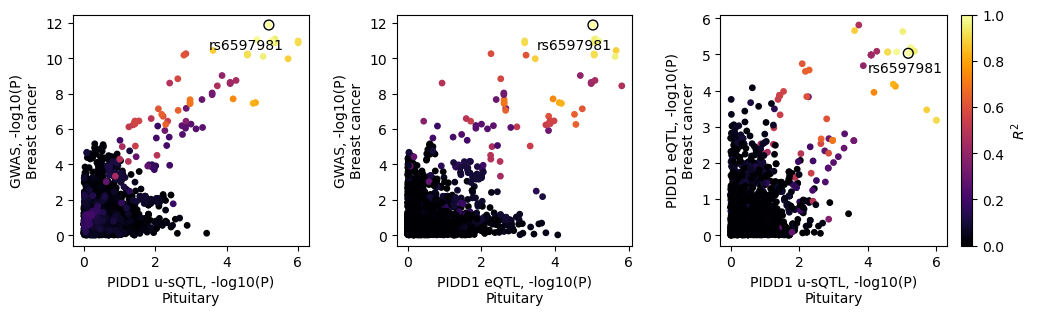

In [48]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2])
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:803017', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0, rasterized=True)
# plt.colorbar(c)
ax[0].set_xlabel('PIDD1 u-sQTL, -log10(P)\nPituitary')
ax[0].set_ylabel('GWAS, -log10(P)\nBreast cancer')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:803017']].P.astype(float)))
x_r = -np.log10(np.array(nom.loc[['chr11:803017']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(3.5, 10.5, 'rs6597981')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:803017', snps_shared]
c=ax[1].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0, rasterized=True)
# plt.colorbar(c)
ax[1].set_xlabel('PIDD1 eQTL, -log10(P)\nPituitary')
ax[1].set_ylabel('GWAS, -log10(P)\nBreast cancer')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:803017']].P.astype(float)))
x_r = -np.log10(np.array(nom_e.loc[['chr11:803017']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(3.5, 10.5, 'rs6597981')



x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:803017', snps_shared]
c=ax[2].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0, rasterized=True)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('PIDD1 u-sQTL, -log10(P)\nPituitary')
ax[2].set_ylabel('PIDD1 eQTL, -log10(P)\nBreast cancer')

x_r = -np.log10(np.array(nom.loc[['chr11:803017']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_e.loc[['chr11:803017']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(4, 4.5, 'rs6597981')

fig.subplots_adjust(wspace=0.35, hspace=5)

plt.savefig('plots/sup_breast-cancer.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_breast-cancer.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_breast-cancer.svg', dpi=300, bbox_inches='tight') 

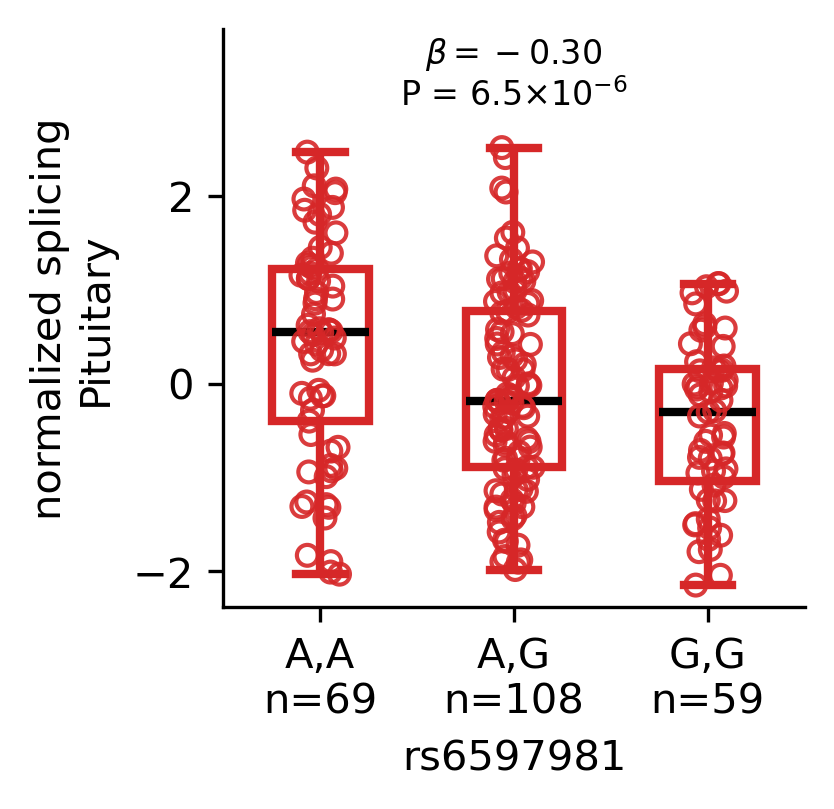

In [49]:
records = get_best_snp_record(vcf_gtex, 'chr11:803017')

ax = make_boxplot_df(qqnorm, 'chr11:802376:802542:clu_21995_-:UP:chr11_803017_N_N_GCST004988', records[0], color='tab:red')
ax.set_xlabel('rs6597981')
ax.set_ylabel('normalized splicing\nPituitary')


_b, _p = nominal_qtl_stats('Pituitary', 'leafcutter',
                           'chr11:802376:802542:clu_21995_-:UP:chr11_803017_N_N_GCST004988', 'chr11:803017')
if _b is not None:
    _yb, _yt = ax.get_ylim(); ax.set_ylim(_yb, _yt + 0.20 * (_yt - _yb))
    ax.text(0.5, 0.99, fmt_qtl(_b, _p), transform=ax.transAxes,
            ha='center', va='top', fontsize=8)

plt.savefig('plots/sup_breast-cancer_pituitary_splicing.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_breast-cancer_pituitary_splicing.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_breast-cancer_pituitary_splicing.svg', dpi=300, bbox_inches='tight') 

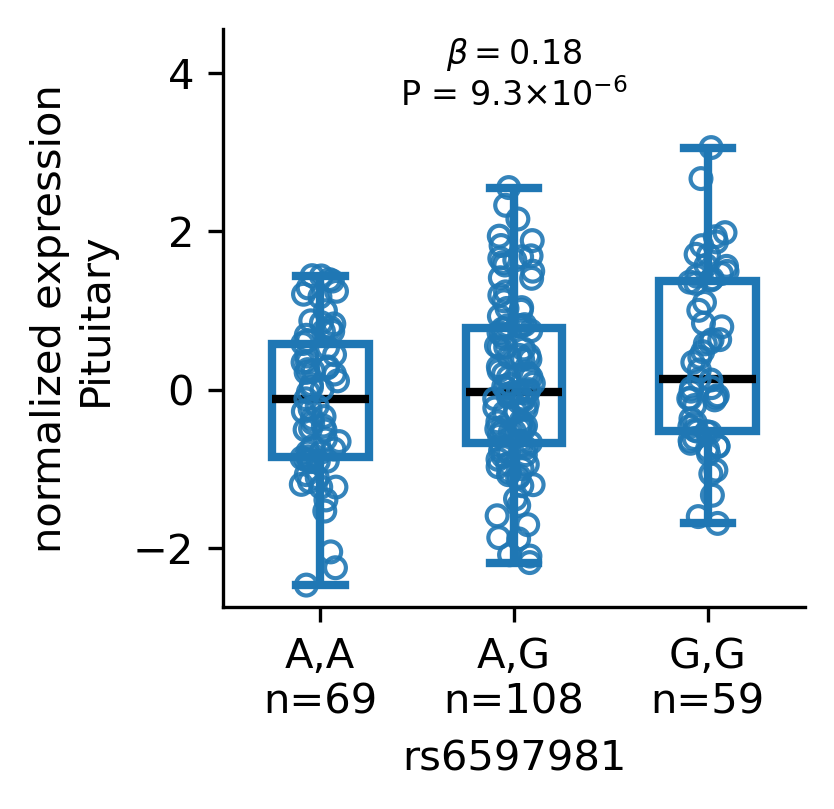

In [50]:
ax = make_boxplot_df(qqnorm_e, 'ENSG00000177595.18:chr11_803017_N_N_GCST004988', records[0], color='tab:blue')
ax.set_xlabel('rs6597981')
ax.set_ylabel('normalized expression\nPituitary')




_b, _p = nominal_qtl_stats('Pituitary', 'expression',
                           'ENSG00000177595.18:chr11_803017_N_N_GCST004988', 'chr11:803017')
if _b is not None:
    _yb, _yt = ax.get_ylim(); ax.set_ylim(_yb, _yt + 0.20 * (_yt - _yb))
    ax.text(0.5, 0.99, fmt_qtl(_b, _p), transform=ax.transAxes,
            ha='center', va='top', fontsize=8)

plt.savefig('plots/sup_breast-cancer_pituitary_expression.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_breast-cancer_pituitary_expression.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_breast-cancer_pituitary_expression.svg', dpi=300, bbox_inches='tight') 

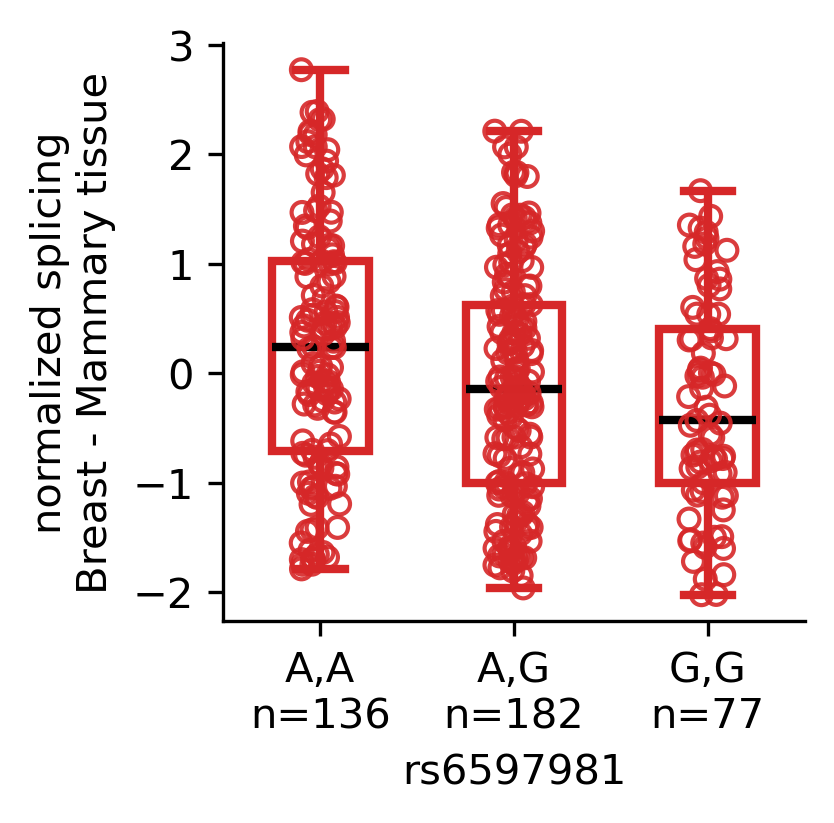

In [51]:
records = get_best_snp_record(vcf_gtex, 'chr11:803017')

ax = make_boxplot_df(qqnorm_bm, 'chr11:802376:802542:clu_22443_-:UP:chr11_803017_N_N_GCST004988', records[0], color='tab:red')
ax.set_xlabel('rs6597981')
ax.set_ylabel('normalized splicing\nBreast - Mammary tissue')

_b, _p = nominal_qtl_stats('Breast-MammaryTissue', 'leafcutter',
                           'chr11:802376:802542:clu_22443_-:UP:chr11_803017_N_N_GCST004988', 'chr11:803017')
if _b is not None:
    _yb, _yt = ax.get_ylim(); ax.set_ylim(_yb, _yt + 0.20 * (_yt - _yb))
    ax.text(0.5, 0.99, fmt_qtl(_b, _p), transform=ax.transAxes,
            ha='center', va='top', fontsize=8)

plt.savefig('plots/sup_breast-cancer_bmt_splicing.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_breast-cancer_bmt_splicing.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_breast-cancer_bmt_splicing.svg', dpi=300, bbox_inches='tight') 

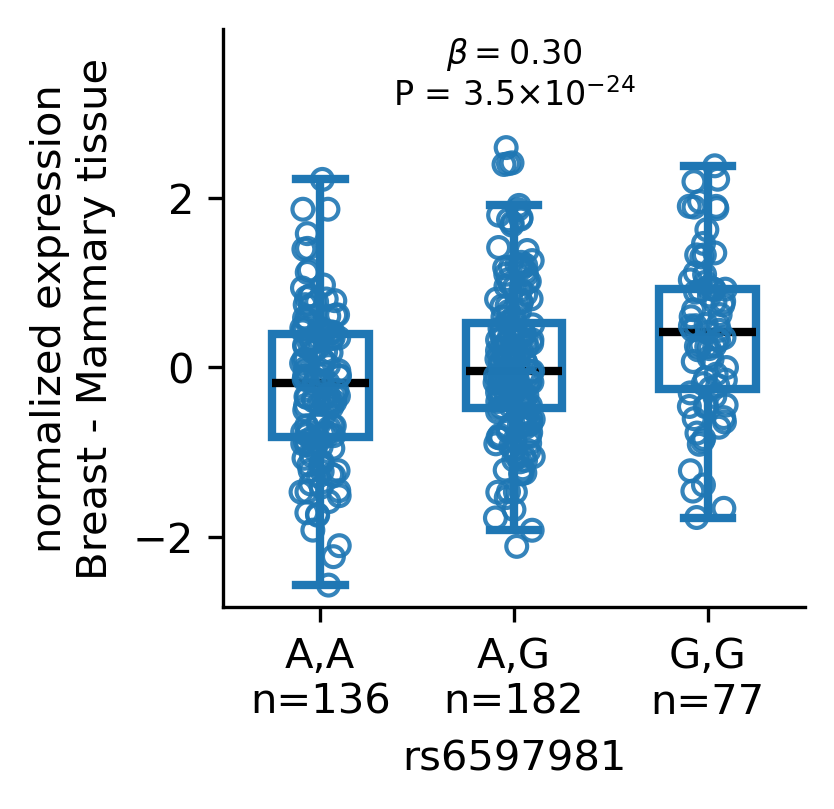

In [52]:
records = get_best_snp_record(vcf_gtex, 'chr11:803017')

ax = make_boxplot_df(qqnorm_bm_e, 'ENSG00000177595.18:chr11_803017_N_N_GCST004988', records[0], color='tab:blue')
ax.set_xlabel('rs6597981')
ax.set_ylabel('normalized expression\nBreast - Mammary tissue')



_b, _p = nominal_qtl_stats('Breast-MammaryTissue', 'expression',
                           'ENSG00000177595.18:chr11_803017_N_N_GCST004988', 'chr11:803017')
if _b is not None:
    _yb, _yt = ax.get_ylim(); ax.set_ylim(_yb, _yt + 0.20 * (_yt - _yb))
    ax.text(0.5, 0.99, fmt_qtl(_b, _p), transform=ax.transAxes,
            ha='center', va='top', fontsize=8)

plt.savefig('plots/sup_breast-cancer_bmt_expression.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_breast-cancer_bmt_expression.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_breast-cancer_bmt_expression.svg', dpi=300, bbox_inches='tight') 

In [53]:
annot_alt = annot.loc[annot.transcript_id == 'ENST00000411829'].copy().reset_index(drop=True)

In [54]:
annot_alt.loc[10, 'end'] = '802376'
annot_alt.transcript_id = ['NMD_whole']*annot_alt.shape[0]

In [55]:
annot_alt = pd.concat([annot, annot_alt], axis=0)

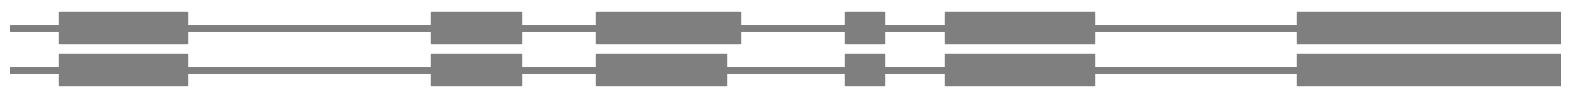

In [56]:
# plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000525445','ENST00000469048',])], 
#                          'ENSG00000185507', 
#                          colores=['tab:gray', 'tab:gray'],  figsize=(20, 1), lwidth=5, 
#                          iso_order=['ENST00000525445','ENST00000469048'])
plot_isoform_annotations(annot_alt.loc[annot_alt.transcript_id.isin(['NMD_whole', 'ENST00000411829'])], 'ENSG00000177595', 
                         colores=['tab:gray']*3, start=802376-1000, end=802542+1000, figsize=(20, 1), lwidth=5, iso_order=None)
plt.savefig('plots/sup_breast-cancer_gene.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_breast-cancer_gene.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_breast-cancer_gene.svg', dpi=300, bbox_inches='tight') 

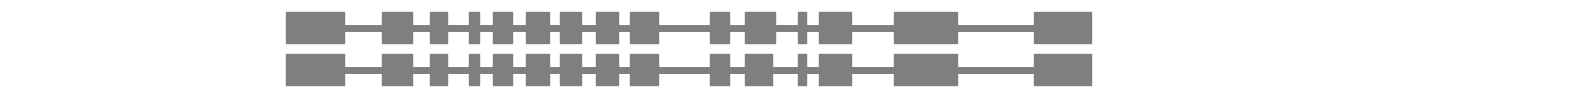

In [57]:
# plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000525445','ENST00000469048',])], 
#                          'ENSG00000185507', 
#                          colores=['tab:gray', 'tab:gray'],  figsize=(20, 1), lwidth=5, 
#                          iso_order=['ENST00000525445','ENST00000469048'])
plot_isoform_annotations(annot_alt.loc[annot_alt.transcript_id.isin(['NMD_whole', 'ENST00000411829'])], 'ENSG00000177595', 
                         colores=['tab:gray']*3, start=802376-5000, end=802542+5000, figsize=(20, 1), lwidth=5, iso_order=None)
# plt.savefig('plots/sup_breast-cancer_gene.png', dpi=300, bbox_inches='tight')
# plt.savefig('plots/sup_breast-cancer_gene.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('plots/sup_breast-cancer_gene.svg', dpi=300, bbox_inches='tight') 

In [58]:
for t, df in annot.loc[annot.gene_id == 'ENSG00000177595'].groupby('transcript_id'):
    print(df)

    #chrom   start     end          gene_id gene_name strand       gene_type  \
269  chr11  799184  799565  ENSG00000177595     PIDD1      -  protein_coding   
276  chr11  799815  800014  ENSG00000177595     PIDD1      -  protein_coding   
283  chr11  800131  800244  ENSG00000177595     PIDD1      -  protein_coding   
287  chr11  800333  800451  ENSG00000177595     PIDD1      -  protein_coding   
297  chr11  800543  800666  ENSG00000177595     PIDD1      -  protein_coding   
308  chr11  800762  800912  ENSG00000177595     PIDD1      -  protein_coding   
313  chr11  800985  801120  ENSG00000177595     PIDD1      -  protein_coding   
322  chr11  801218  801365  ENSG00000177595     PIDD1      -  protein_coding   
331  chr11  801445  801624  ENSG00000177595     PIDD1      -  protein_coding   
341  chr11  801965  802090  ENSG00000177595     PIDD1      -  protein_coding   
348  chr11  802195  802396  ENSG00000177595     PIDD1      -  protein_coding   
356  chr11  802543  802597  ENSG00000177